In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import torch
from transformers import RobertaTokenizer, RobertaForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from utils import balance_by_min_class

In [2]:
# 1. Use GPU
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [ ]:
# Load the pre-existing deduplicated splits
train_df = pd.read_csv('../data/train_data.csv').dropna(subset=['content', 'Sentiment'])
test_df = pd.read_csv('../data/test_data.csv').dropna(subset=['content', 'Sentiment'])

# Create a validation set out of the training split
train_df, val_df = train_test_split(train_df, test_size=0.125, random_state=42, stratify=train_df['Sentiment'])

# Balance the training set by downsampling every class to the smallest.
print("Before balancing:", train_df['Sentiment'].value_counts().to_dict())
train_df = balance_by_min_class(train_df, label_col='Sentiment', random_state=42)

print(f"\nTrain: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print("Train counts (Balanced):", train_df['Sentiment'].value_counts().to_dict())

Before balancing: {'Positive': 66095, 'Negative': 15262, 'Neutral': 4172}

Train: 12516 | Val: 12219 | Test: 24438
Train counts (Balanced): {'Positive': 4172, 'Neutral': 4172, 'Negative': 4172}


In [ ]:
# Sanity checks to prevent leakage

def _make_keys(df):
    return set(zip(df['appName'].astype(str), df['content'].astype(str)))

for name, df_ in [('train', train_df), ('val', val_df), ('test', test_df)]:
    assert df_[['appName', 'content', 'clean_content', 'Sentiment']].isna().any(axis=1).sum() == 0, f"Missing core fields in {name}"
    assert (df_['content'].astype(str).str.strip() == '').sum() == 0, f"Empty content in {name}"

train_keys = _make_keys(train_df)
val_keys = _make_keys(val_df)
test_keys = _make_keys(test_df)

assert len(train_keys & val_keys) == 0, "Train/Val overlap detected"
assert len(train_keys & test_keys) == 0, "Train/Test overlap detected"
assert len(val_keys & test_keys) == 0, "Val/Test overlap detected"

print("Sanity checks passed")
print(f"Train rows: {len(train_df)} | Val rows: {len(val_df)} | Test rows: {len(test_df)}")
print("Train label counts:", train_df['Sentiment'].value_counts().to_dict())
print("Val label counts:", val_df['Sentiment'].value_counts().to_dict())
print("Test label counts:", test_df['Sentiment'].value_counts().to_dict())

Sanity checks passed
Train rows: 12516 | Val rows: 12219 | Test rows: 24438
Train label counts: {'Positive': 4172, 'Neutral': 4172, 'Negative': 4172}
Val label counts: {'Positive': 9443, 'Negative': 2180, 'Neutral': 596}
Test label counts: {'Positive': 18885, 'Negative': 4361, 'Neutral': 1192}


In [5]:
# Convert text labels (Positive/Negative/Neutral) to numbers (0, 1, 2)
le = LabelEncoder()
train_labels = le.fit_transform(train_df['Sentiment'])
val_labels = le.transform(val_df['Sentiment'])
test_labels = le.transform(test_df['Sentiment'])

In [6]:
# Load the RoBERTa Tokenizer
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

In [7]:
# Tokenize raw text with fixed-length padding so train/val/test tensors match shape.
train_encodings = tokenizer(train_df['content'].tolist(), truncation=True, padding='max_length', max_length=128)
val_encodings   = tokenizer(val_df['content'].tolist(),   truncation=True, padding='max_length', max_length=128)
test_encodings  = tokenizer(test_df['content'].tolist(),  truncation=True, padding='max_length', max_length=128)

In [8]:
# Create a Custom PyTorch Dataset
class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

train_dataset = ReviewDataset(train_encodings, train_labels)
val_dataset = ReviewDataset(val_encodings, val_labels)
test_dataset = ReviewDataset(test_encodings, test_labels)

In [9]:
# 6. Load the pre-trained RoBERTa model (configured for 3 labels)
model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=3)
model.to(device)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [ ]:
# Define the evaluation metrics
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    f1 = f1_score(labels, preds, average='macro')
    precision = precision_score(labels, preds, average='macro')
    recall = recall_score(labels, preds, average='macro')
    return {'macro_f1': f1, 'macro_precision': precision, 'macro_recall': recall}

In [ ]:
# warmup_steps computed explicitly from the training set size
batch_size = 16
num_epochs = 10
steps_per_epoch = -(-len(train_dataset) // batch_size) 
total_steps = steps_per_epoch * num_epochs
warmup_steps = int(0.1 * total_steps)
print(f'Training steps: {total_steps} (warmup: {warmup_steps})')

training_args = TrainingArguments(
    output_dir='./results_balanced',
    num_train_epochs=num_epochs,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=warmup_steps,
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    save_total_limit=2,
    report_to='none',
    seed=42,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("Starting Training...")
trainer.train()

Training steps: 7830 (warmup: 783)
Starting Training...


/Users/jakobaune/anaconda3/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Macro F1,Macro Precision,Macro Recall
1,0.948783,0.524045,0.634827,0.621751,0.661034
2,0.726314,0.592731,0.609181,0.595109,0.672403
3,0.650402,0.730093,0.587562,0.601612,0.674808


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/jakobaune/anaconda3/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/jakobaune/anaconda3/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=2349, training_loss=0.7531440315879929, metrics={'train_runtime': 1547.7982, 'train_samples_per_second': 80.863, 'train_steps_per_second': 5.059, 'total_flos': 2469845652212736.0, 'train_loss': 0.7531440315879929, 'epoch': 3.0})


--- FINAL ROBERTA RESULTS ---


/Users/jakobaune/anaconda3/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Macro F1-score: 0.6366
Macro Precision: 0.6234
Macro Recall: 0.6609

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.74      0.77      0.75      4361
     Neutral       0.19      0.32      0.24      1192
    Positive       0.94      0.89      0.91     18885

    accuracy                           0.84     24438
   macro avg       0.62      0.66      0.64     24438
weighted avg       0.87      0.84      0.85     24438



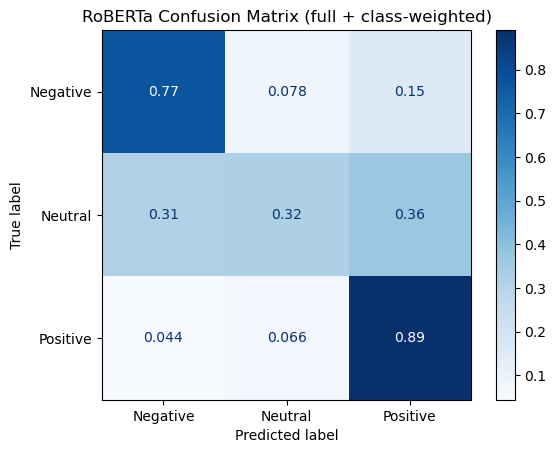

ChatGPT Macro F1: 0.6182
Claude Macro F1: 0.6601
Gemini Macro F1: 0.6314


In [12]:
import matplotlib.pyplot as plt

# Evaluation on the Test Set

print("\n--- FINAL ROBERTA RESULTS ---")
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

macro_f1 = f1_score(labels, preds, average='macro')
macro_precision = precision_score(labels, preds, average='macro')
macro_recall = recall_score(labels, preds, average='macro')

print(f"Macro F1-score: {macro_f1:.4f}")
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall: {macro_recall:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(labels, preds, target_names=le.classes_))


ConfusionMatrixDisplay.from_predictions(labels, preds, display_labels=le.classes_, cmap='Blues', normalize='true')
plt.title('RoBERTa Confusion Matrix (full + class-weighted)')
plt.show()

# Per-app F1 breakdown
test_df = test_df.copy()
test_df['prediction'] = le.inverse_transform(preds)
for app in sorted(test_df['appName'].unique()):
    sub = test_df[test_df['appName'] == app]
    f1_app = f1_score(sub['Sentiment'], sub['prediction'], average='macro')
    print(f"{app} Macro F1: {f1_app:.4f}")

In [ ]:
import numpy as np
import pandas as pd
import torch
from transformers import RobertaForSequenceClassification, Trainer

pd.set_option('display.max_colwidth', None)

# If predictions are missing, load from the best checkpoint
if 'prediction' not in test_df.columns:
    print("Predictions not found in test_df. Loading best model from checkpoint to generate them (takes < 1 min)...")
    
    # Check if a model is already loaded in the environment
    if 'model' not in locals():
        print("Loading best model from ./results_full/checkpoint-3592 ...")
        device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
        model = RobertaForSequenceClassification.from_pretrained('./results_full/checkpoint-3592')
        model.to(device)
        
    if 'trainer' not in locals():
        trainer = Trainer(model=model)
    
    print("Running predictions on test set...")
    predictions = trainer.predict(test_dataset)
    preds = np.argmax(predictions.predictions, axis=-1)
    test_df['prediction'] = le.inverse_transform(preds)
    print("Done!\n")

for sentiment in ['Positive', 'Neutral', 'Negative']:
    print(f"\n{'='*80}")
    print(f"10 Examples of TRUTH: {sentiment}")
    print(f"{'='*80}\n")
    
    examples = test_df[test_df['Sentiment'] == sentiment].head(10)
    for idx, row in examples.iterrows():
        print(f"Review: {row['content']}")
        print(f"Truth: {row['Sentiment']} | Predicted: {row['prediction']}\n")
        print("-"*80 + "\n")



10 Examples of TRUTH: Positive

Review: good...💝
Truth: Positive | Predicted: Positive

--------------------------------------------------------------------------------

Review: Great help returning assistance I need in the hope to start creating online training
Truth: Positive | Predicted: Positive

--------------------------------------------------------------------------------

Review: very good thanks google
Truth: Positive | Predicted: Positive

--------------------------------------------------------------------------------

Review: it's an amazing and wonderful app everyone should have it ❤️
Truth: Positive | Predicted: Positive

--------------------------------------------------------------------------------

Review: Easy to use, free to use, truly enjoyable experience, enriching lives with it's utility
Truth: Positive | Predicted: Positive

--------------------------------------------------------------------------------

Review: yah har chij mein help karta hai ki bahut achch